<a href="https://colab.research.google.com/github/thanu-shree-29/Attendance-System/blob/main/Attendance_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving students.csv to students.csv
Saving attendance.csv to attendance.csv


In [3]:
!pip install reportlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 7.6 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=48c43f37e1adeab2ad130ab7794eab4ef5d29aa32adf05cd5811f83a123590d9
  Stored in directory: /root/.cache/pip/wheels/5f/d4/d7/4189b07b5902ee9f3ce0dbb14909fbe8037c39d6c63ffd49c9
Successfully built htmlmin


In [1]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.2 MB/s eta 0:00:00


,Student_ID,Full_Name,Date,Subject,Attendance_Status
0,S00001,Donna Williams,2024-03-12,Arabic,PRESENT
1,S00001,Donna Williams,2024-03-18,Geography,PRESENT
2,S00001,Donna Williams,2024-04-24,English,absnt
3,S00001,Donna Williams,2024-05-03,Science,Absent
4,S00001,Donna Williams,2024-05-07,Math,Present
...,...,...,...,...,...
364675,S12156,Shannon Brown,2024-11-26,History,excused
364676,S12156,Shannon Brown,2024-12-17,History,Late
364677,S12156,Shannon Brown,2025-01-17,Arabic,Absent
364678,S12156,Shannon Brown,2025-02-10,Math,absnt


,Student_ID,Full_Name,Attendance_Percentage
0,S00001,Donna Williams,12.820513
1,S00002,John Stafford,32.000000
2,S00003,Chad Harper,4.000000
3,S00004,Anthony Martin,4.166667
4,S00005,Mary Stone,17.241379
...,...,...,...
12151,S12152,Justin Owens,9.090909
12152,S12153,Brandi Kennedy,3.846154
12153,S12154,Chase Douglas,13.043478
12154,S12155,Dawn Ward,8.108108


🏆 TOPPERS


,Student_ID,Full_Name,Attendance_Percentage
10430,S10431,Jessica Smith,44.117647
7550,S07551,Christopher Alvarado,41.176471
9356,S09357,Nicholas Moran,40.000000
1285,S01286,Patrick Mitchell,40.000000
9971,S09972,Patricia Bell,36.363636
...,...,...,...
1923,S01924,christine hernandez,0.000000
10185,S10186,Lydia Gregory,0.000000
3108,S03109,Michael Hendricks,0.000000
11003,S11004,Briana Coffey,0.000000


⚠ DEFAULTERS


,Student_ID,Full_Name,Attendance_Percentage
0,S00001,Donna Williams,12.820513
1,S00002,John Stafford,32.000000
2,S00003,Chad Harper,4.000000
3,S00004,Anthony Martin,4.166667
4,S00005,Mary Stone,17.241379
...,...,...,...
12151,S12152,Justin Owens,9.090909
12152,S12153,Brandi Kennedy,3.846154
12153,S12154,Chase Douglas,13.043478
12154,S12155,Dawn Ward,8.108108


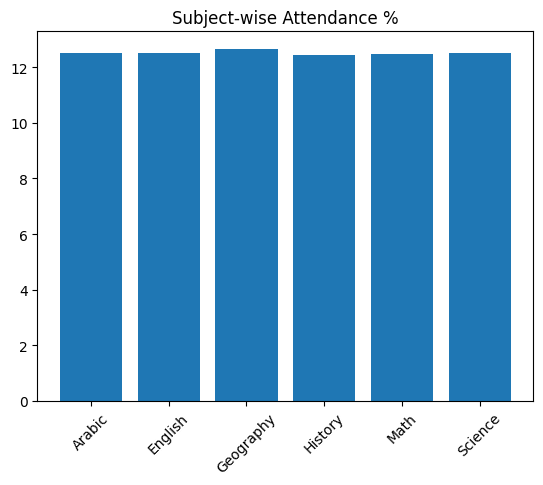

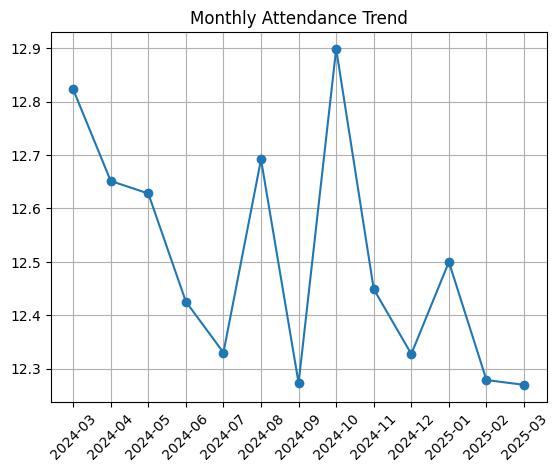

📄 PDF Generated: Attendance_Report.pdf


In [4]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

# =========================
# 2. UPLOAD CSV FILES
# =========================
students = pd.read_csv("students.csv")
attendance = pd.read_csv("attendance.csv")

# =========================
# 3. DATABASE SETUP
# =========================
conn = sqlite3.connect("Aplus_Attendance.db")

students.to_sql("Students", conn, if_exists="replace", index=False)
attendance.to_sql("Attendance", conn, if_exists="replace", index=False)

# =========================
# 4. JOIN QUERY (CORE DBMS)
# =========================
df = pd.read_sql("""
SELECT s.Student_ID, s.Full_Name, a.Date, a.Subject, a.Attendance_Status
FROM Students s
JOIN Attendance a
ON s.Student_ID = a.Student_ID
""", conn)

display(df)

# =========================
# 5. ATTENDANCE PERCENTAGE
# =========================
result = pd.read_sql("""
SELECT
    s.Student_ID,
    s.Full_Name,
    COUNT(CASE WHEN a.Attendance_Status='Present' THEN 1 END)*100.0/COUNT(*) AS Attendance_Percentage
FROM Students s
JOIN Attendance a
ON s.Student_ID = a.Student_ID
GROUP BY s.Student_ID, s.Full_Name
""", conn)

display(result)

# =========================
# 6. TOPPER LIST
# =========================
topper = result.sort_values(by="Attendance_Percentage", ascending=False)
print("🏆 TOPPERS")
display(topper)

# =========================
# 7. DEFAULTER LIST
# =========================
defaulter = result[result["Attendance_Percentage"] < 75]
print("⚠ DEFAULTERS")
display(defaulter)

# =========================
# 8. SUBJECT WISE ANALYSIS
# =========================
subject = pd.read_sql("""
SELECT Subject,
COUNT(CASE WHEN Attendance_Status='Present' THEN 1 END)*100.0/COUNT(*) AS Percentage
FROM Attendance
GROUP BY Subject
""", conn)

plt.bar(subject["Subject"], subject["Percentage"])
plt.title("Subject-wise Attendance %")
plt.xticks(rotation=45)
plt.show()

# =========================
# 9. MONTHLY ANALYSIS
# =========================
attendance["Date"] = pd.to_datetime(attendance["Date"])
attendance["Month"] = attendance["Date"].dt.to_period("M").astype(str)

attendance.to_sql("Temp", conn, if_exists="replace", index=False)

monthly = pd.read_sql("""
SELECT Month,
COUNT(CASE WHEN Attendance_Status='Present' THEN 1 END)*100.0/COUNT(*) AS Percentage
FROM Temp
GROUP BY Month
""", conn)

plt.plot(monthly["Month"], monthly["Percentage"], marker='o')
plt.title("Monthly Attendance Trend")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# =========================
# 10. PDF REPORT GENERATION (A+ FEATURE ⭐)
# =========================
pdf = SimpleDocTemplate("Attendance_Report.pdf")
styles = getSampleStyleSheet()
content = []

content.append(Paragraph("Student Attendance Report", styles['Title']))
content.append(Spacer(1, 12))

# Topper table
top_data = [["Name", "Attendance %"]] + topper[["Full_Name","Attendance_Percentage"]].values.tolist()

table = Table(top_data)
table.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),colors.grey),
    ('TEXTCOLOR',(0,0),(-1,0),colors.whitesmoke),
    ('GRID',(0,0),(-1,-1),0.5,colors.black)
]))

content.append(table)

pdf.build(content)

print("📄 PDF Generated: Attendance_Report.pdf")